In [1]:
library(Seurat)
library(tidyverse)
library(presto)
library(glmGamPoi)
library(future)
library(SeuratObject)
library(viridis)
# library(ggpubr)
library(scales)
library(presto)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(purrr)
library(tidyr)

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.4.3”



Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘presto’ was built under R version 4.4.3”
Loading required pa

In [2]:
# Load Harmony integrated object
# harmony_obj <- readRDS('/mnt/18T/chibao/gliomas/data_official/00_raw_data_adult/03_integrated/01_harmony/orig.ident/obj/harmony_integrated_orig.ident.rds')
# harmony_obj
# harmony_obj@meta.data |> head(2)

# Load RPCA integrated object
rpca_obj <- readRDS('/mnt/18T/chibao/gliomas/data_official/00_raw_data_adult/03_integrated/02_rpca/orig.ident/obj/01_rpca_integrated_orig.ident.rds')
rpca_obj
rpca_obj@meta.data |> head(2)

An object of class Seurat 
74475 features across 302646 samples within 2 assays 
Active assay: SCT (35869 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap, rpca, umap.rpca

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.1,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAAGTCAAGCG-1,PRJNA1125010,6520,1839,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,6.119632,singlet,⋯,6,6,20,19,18,22,17,13,11,11
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCACATTGCCGG-1,PRJNA1125010,4533,1962,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,14.780499,singlet,⋯,1,3,17,12,23,18,29,27,32,32


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



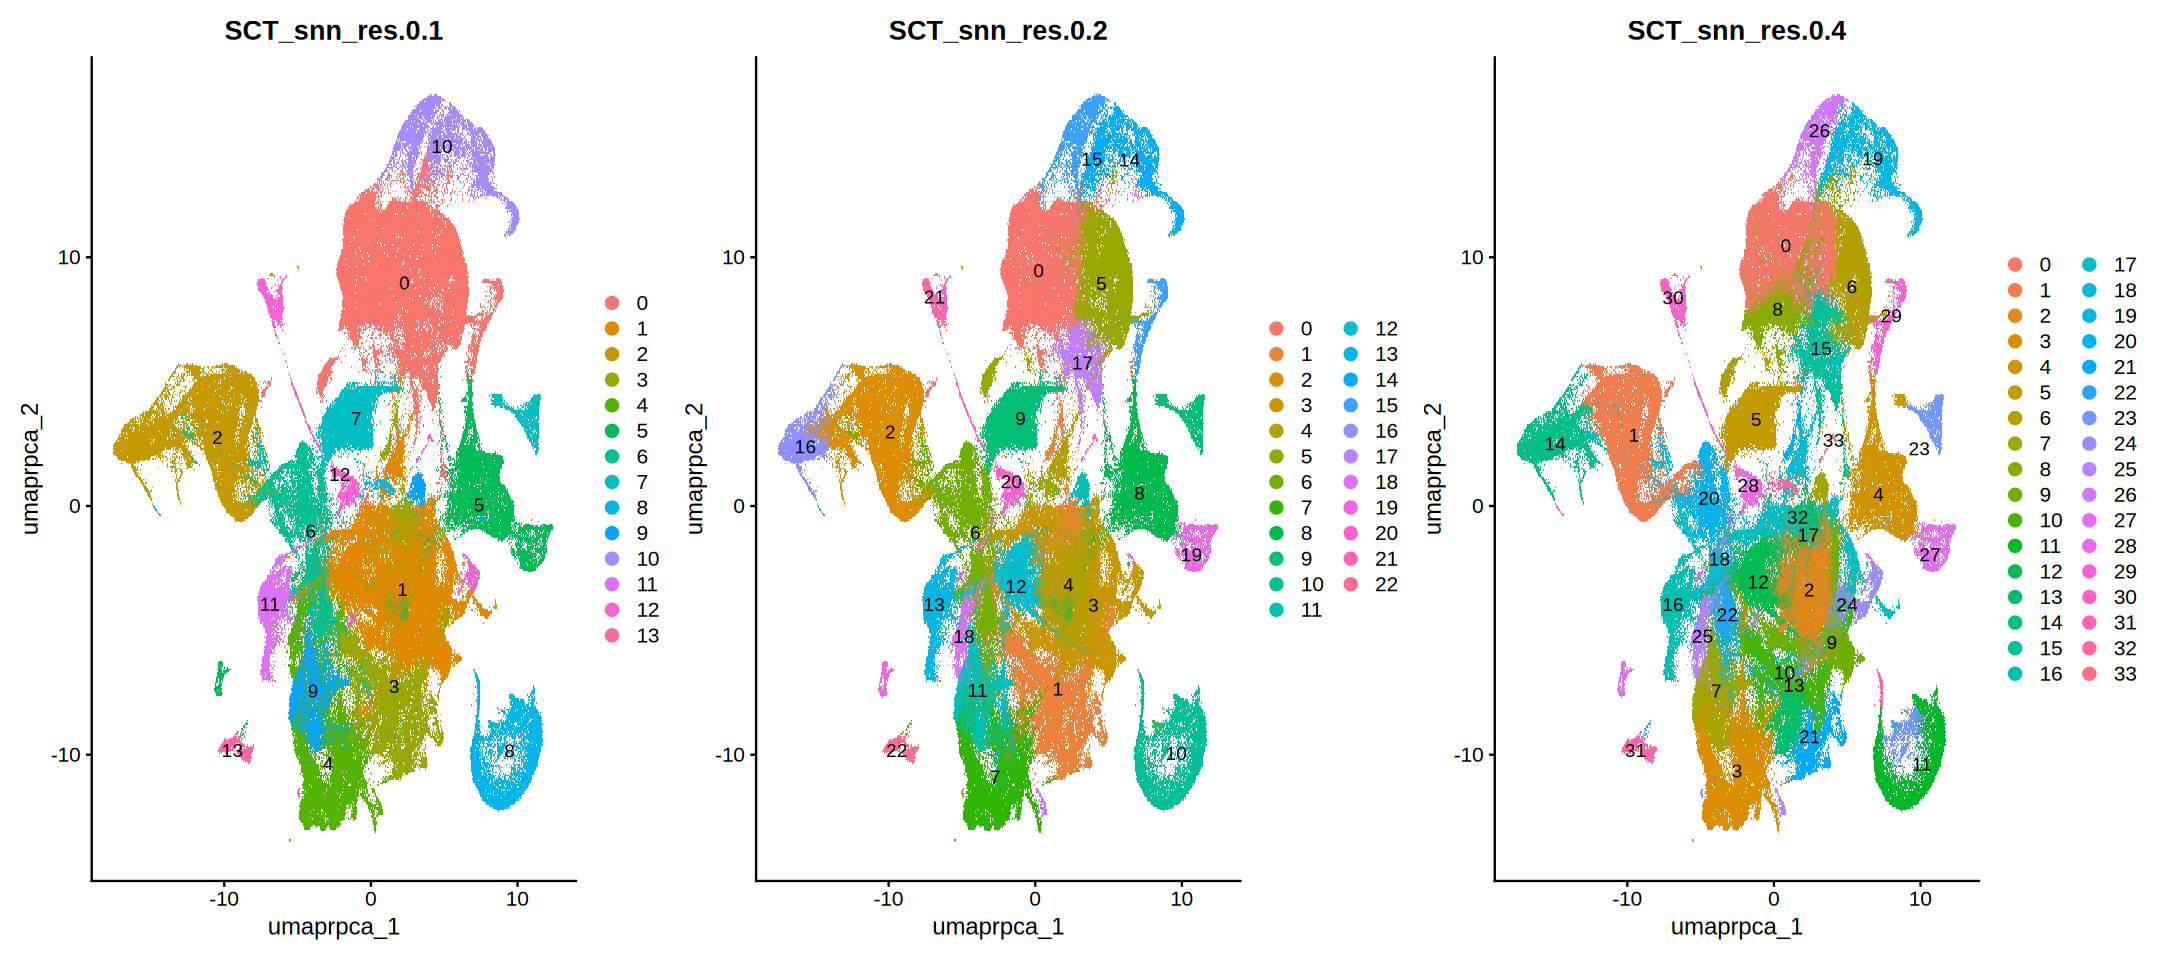

In [3]:
options(repr.plot.width = 18, repr.plot.height = 8)
p1 <- DimPlot(rpca_obj, reduction = 'umap.rpca', group.by = 'SCT_snn_res.0.1', label = TRUE)
p2 <- DimPlot(rpca_obj, reduction = 'umap.rpca', group.by = 'SCT_snn_res.0.2', label = TRUE)
p3 <- DimPlot(rpca_obj, reduction = 'umap.rpca', group.by = 'SCT_snn_res.0.4', label = TRUE)

p1 + p2 + p3 

In [4]:
# harmony_obj <- PrepSCTFindMarkers(harmony_obj, assay = "SCT", verbose = TRUE)
rpca_obj <- PrepSCTFindMarkers(rpca_obj, assay = "SCT", verbose = TRUE)

Found 9 SCT models. Recorrecting SCT counts using minimum median counts: 1874



In [ ]:
# # Marker for Harmony
# Idents(harmony_obj) <- 'SCT_snn_res.0.08'

# harmony_markers <- FindAllMarkers(harmony_obj,
#                               assay = "SCT",
#                               only.pos = TRUE,
#                               min.pct = 0.25, 
#                               logfc.threshold = 0.25,
#                               test.use = "wilcox")

rpca_obj <- PrepSCTFindMarkers(rpca_obj, assay = "SCT", verbose = TRUE)

# Marker for RPCA
# 0.1 resolution 
Idents(rpca_obj) <- 'SCT_snn_res.0.1'

rpca_markers_0.1 <- FindAllMarkers(rpca_obj,
                              assay = "SCT",
                              only.pos = TRUE,
                              min.pct = 0.25,
                              logfc.threshold = 0.25,
                              test.use = "wilcox")
# 0.2 resolution
Idents(rpca_obj) <- 'SCT_snn_res.0.2'

rpca_markers_0.2 <- FindAllMarkers(rpca_obj,
                              assay = "SCT",
                              only.pos = TRUE,
                              min.pct = 0.25,
                              logfc.threshold = 0.25,
                              test.use = "wilcox")    

# 0.4 resolution              
Idents(rpca_obj) <- 'SCT_snn_res.0.4'

rpca_markers_0.4 <- FindAllMarkers(rpca_obj,
                              assay = "SCT",
                              only.pos = TRUE,
                              min.pct = 0.25,
                              logfc.threshold = 0.25,
                              test.use = "wilcox")              

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18

Calculating cluster 19

Calculating cluster 20

Calculating cluster 21

Calculating cluster 22



In [ ]:
# Arrange by avg_log2FC
# harmony_markers <- harmony_markers |> arrange(desc(avg_log2FC))
rpca_markers_0.1 <- rpca_markers_0.1 |> arrange(desc(avg_log2FC))
rpca_markers_0.2 <- rpca_markers_0.2 |> arrange(desc(avg_log2FC))
rpca_markers_0.4 <- rpca_markers_0.4 |> arrange(desc(avg_log2FC))
# Save markers in the csv format 
# write.csv(harmony_markers, file = '/mnt/18T/chibao/gliomas/data_official/00_raw_data_adult/03_integrated/01_harmony/orig.ident/markers/harmony_markers.csv')
write.csv(rpca_markers_0.1, file = '/mnt/18T/chibao/gliomas/data_official/01_integrated_obj/new/markers/rpca_markers_0.1.csv')
write.csv(rpca_markers_0.2, file = '/mnt/18T/chibao/gliomas/data_official/01_integrated_obj/new/markers/rpca_markers_0.2.csv')
write.csv(rpca_markers_0.4, file = '/mnt/18T/chibao/gliomas/data_official/01_integrated_obj/new/markers/rpca_markers_0.4.csv')

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



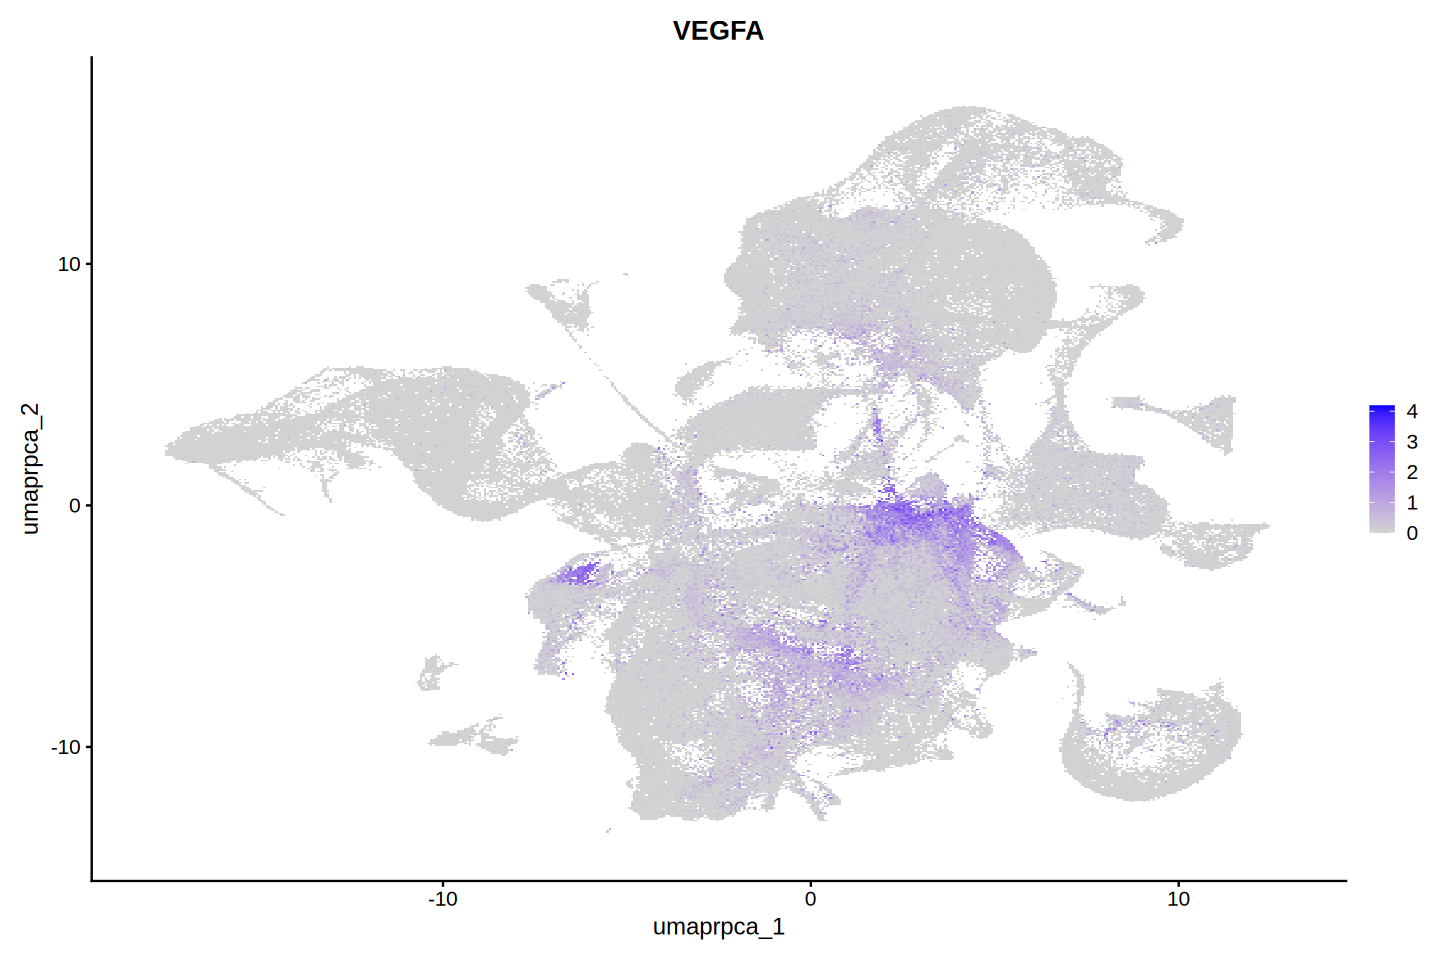

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)
# 'PDGFRA', 'OLIG2', 'SOX10'
FeaturePlot(rpca_obj_cleaned, features = c('SOX8', 'SOX6', 'SMOC1', 'DLL3', 'GRIA4', 'DLGAP1', 'NXPH1', 'SLC1A1'), reduction = 'umap.rpca', ncol = 2, cols = c('lightgrey', 'red'))

In [ ]:
# Range
# top_markers <- cluster1$gene[1:15]
# top_markers <- c('TMEM119', 'TREM2', 'P2RY12', "CX3CR1", "GPR34", "SALL1", "CSF1R")
top_markers <- c('STMN2', 'VGF', 'UCHL1')
# top_markers <- c("APC", "CNTNAP2", "CNP", "MAG", "MBP", "MOG", "PLP1", "RTN4", "OMG", "TPPP")


# Flatten the markers for DotPlot
markers_genes <- unlist(top_markers)
markers_genes <- make.unique(markers_genes)

# Set factor levels in the order of your original markers vector
markers_genes <- factor(markers_genes, levels = markers_genes)

# Create a mapping from gene -> "Cluster0:Gene" label
label_map <- setNames(
  paste0("ClusterX:", markers_genes),
  markers_genes
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


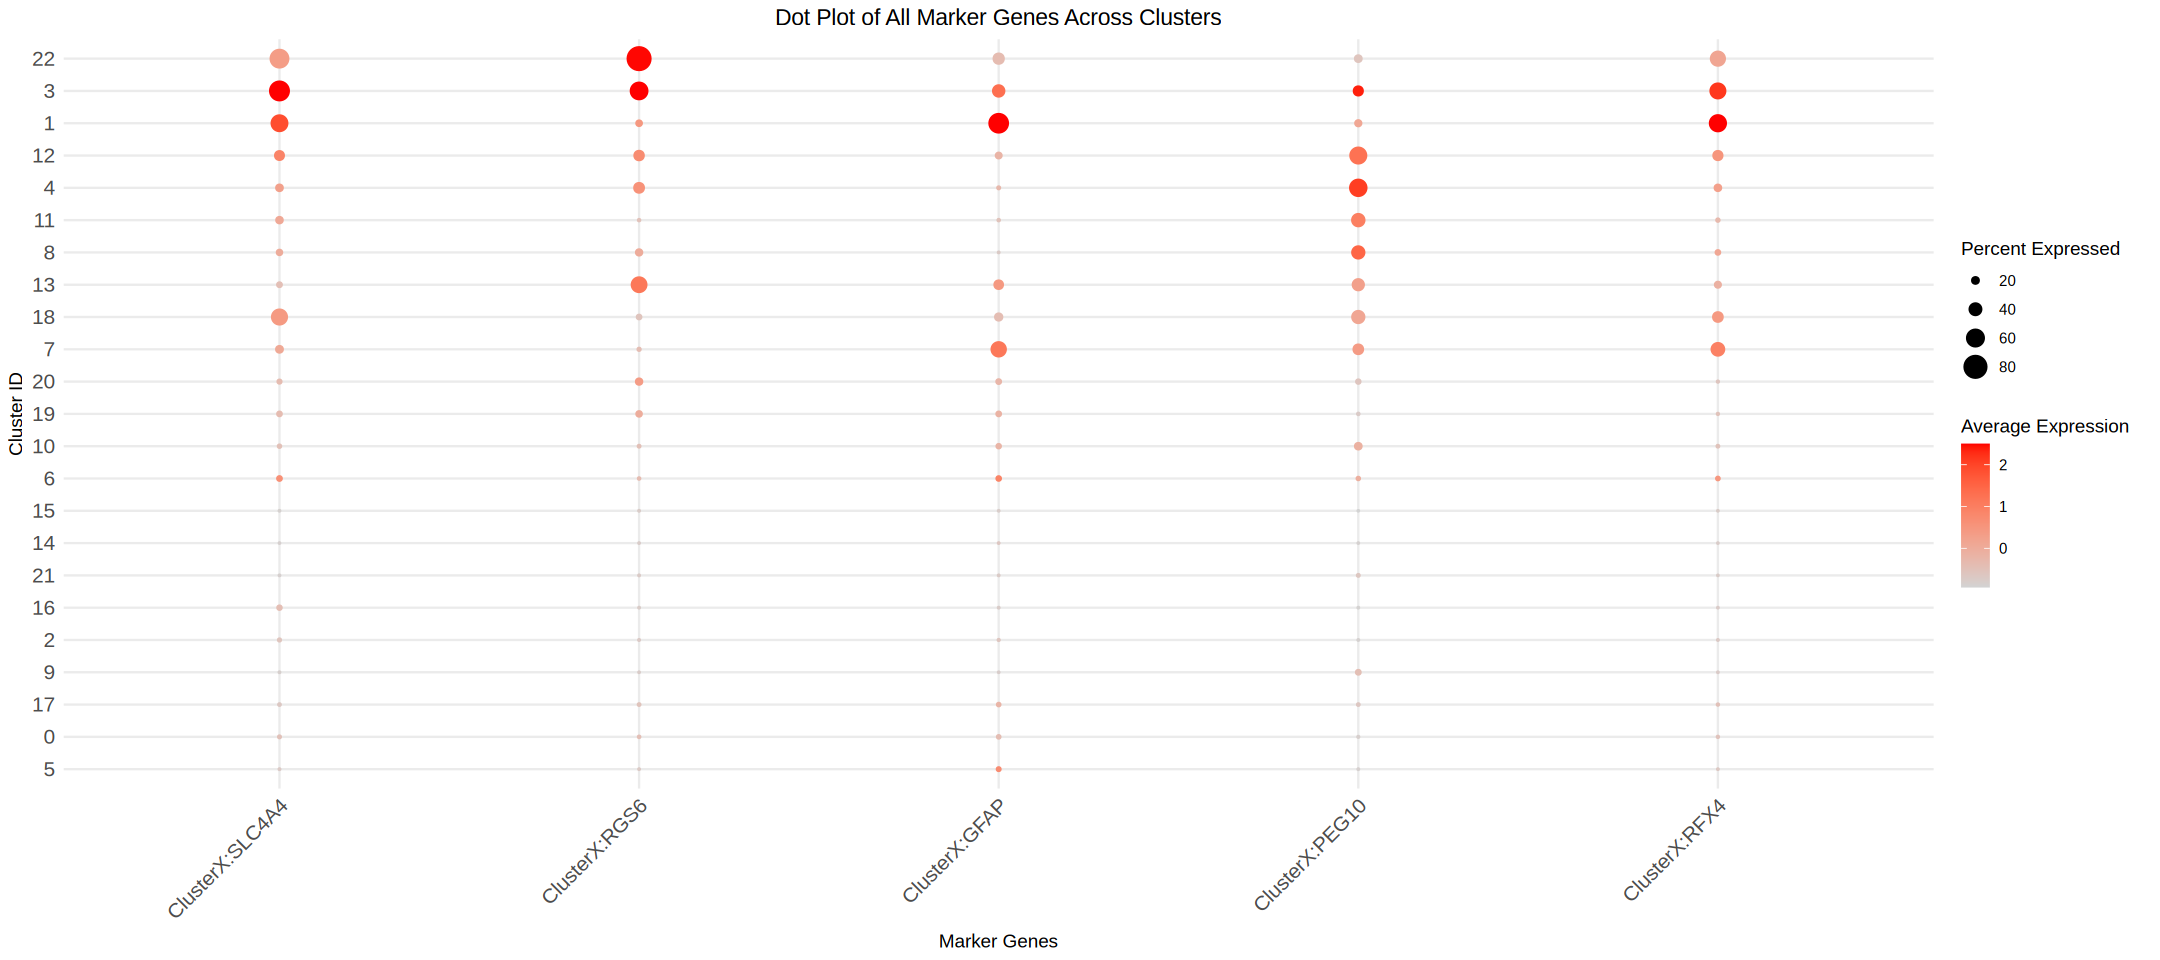

In [ ]:
options(repr.plot.width = 18, repr.plot.height = 8)
Idents(rpca_obj_cleaned) <- 'SCT_snn_res.0.2' # Ensure the correct cluster identities are set
p <- DotPlot(rpca_obj_cleaned, features = markers_genes, cluster.idents = TRUE) +
  scale_color_gradient(low = "lightgrey", high = "red") +
  theme_minimal() +
  xlab("Marker Genes") +
  ylab("Cluster ID") +
  ggtitle("Dot Plot of All Marker Genes Across Clusters") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    plot.title  = element_text(hjust = 0.5)
  ) +
  # Override labels so "CD3D" is displayed as "T_cells:CD3D", etc.
  scale_x_discrete(labels = label_map)

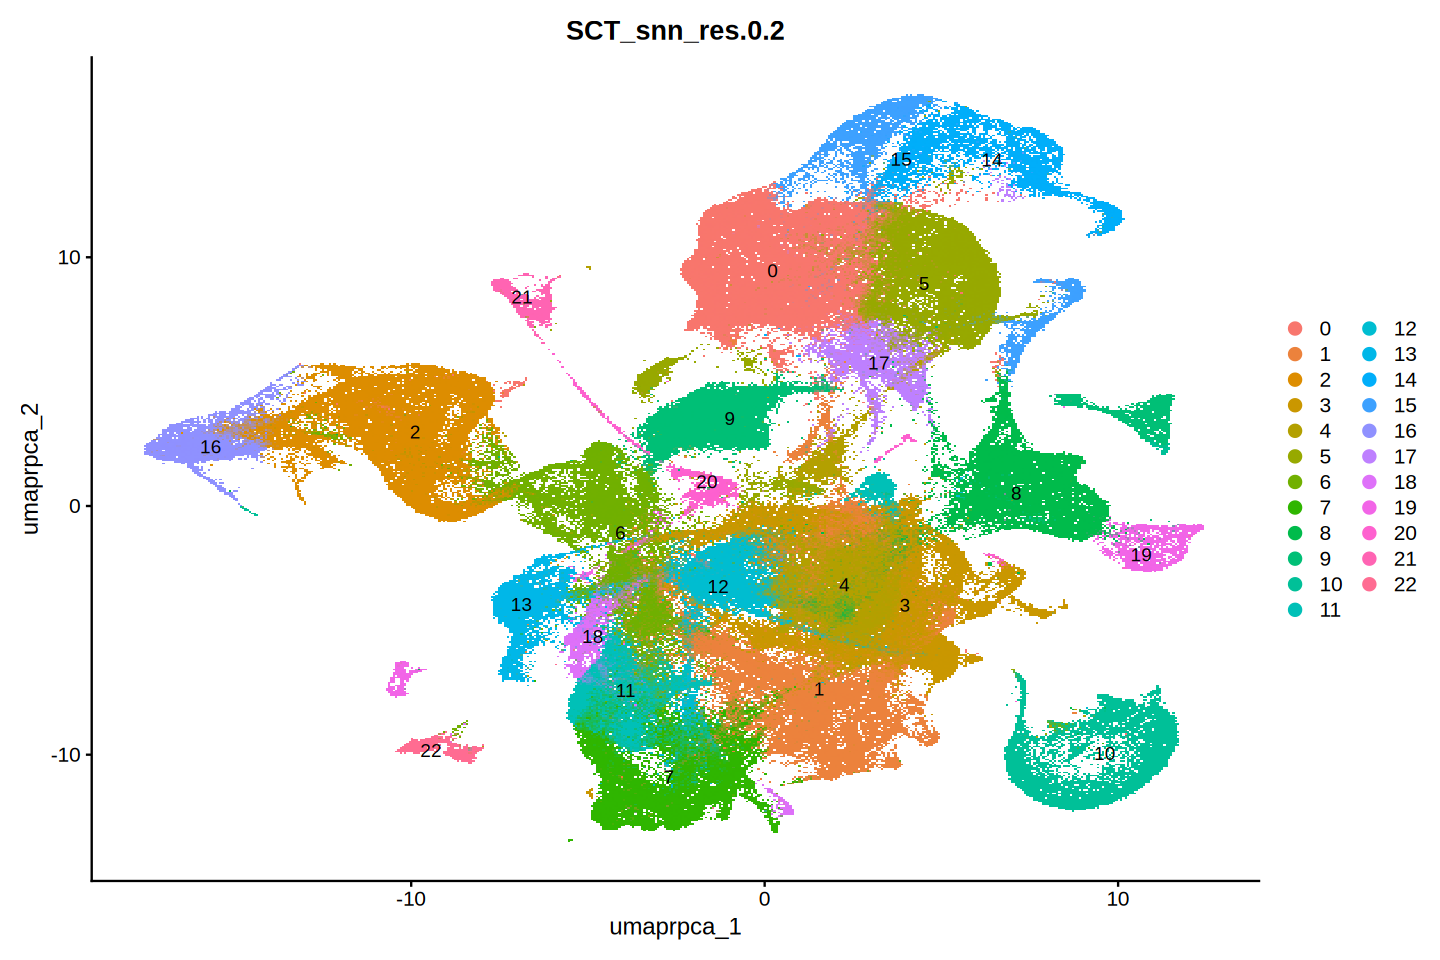

In [7]:
options(repr.plot.width = 12, repr.plot.height = 8)
p2

# GO Pathway

In [9]:
cluster0_genes <- rpca_markers_0.2 |> filter(cluster == 0 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster1_genes <- rpca_markers_0.2 |> filter(cluster == 1 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster2_genes <- rpca_markers_0.2 |> filter(cluster == 2 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster3_genes <- rpca_markers_0.2 |> filter(cluster == 3 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster4_genes <- rpca_markers_0.2 |> filter(cluster == 4 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster5_genes <- rpca_markers_0.2 |> filter(cluster == 5 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster6_genes <- rpca_markers_0.2 |> filter(cluster == 6 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster7_genes <- rpca_markers_0.2 |> filter(cluster == 7 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster8_genes <- rpca_markers_0.2 |> filter(cluster == 8 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster9_genes <- rpca_markers_0.2 |> filter(cluster == 9 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster10_genes <- rpca_markers_0.2 |> filter(cluster == 10 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster11_genes <- rpca_markers_0.2 |> filter(cluster == 11 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster12_genes <- rpca_markers_0.2 |> filter(cluster == 12 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster13_genes <- rpca_markers_0.2 |> filter(cluster == 13 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster14_genes <- rpca_markers_0.2 |> filter(cluster == 14 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster15_genes <- rpca_markers_0.2 |> filter(cluster == 15 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster16_genes <- rpca_markers_0.2 |> filter(cluster == 16 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster17_genes <- rpca_markers_0.2 |> filter(cluster == 17 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster18_genes <- rpca_markers_0.2 |> filter(cluster == 18 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster19_genes <- rpca_markers_0.2 |> filter(cluster == 19 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster20_genes <- rpca_markers_0.2 |> filter(cluster == 20 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster21_genes <- rpca_markers_0.2 |> filter(cluster == 21 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster22_genes <- rpca_markers_0.2 |> filter(cluster == 22 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)

In [ ]:
cluster0_genes <- rpca_markers_0.4 |> filter(cluster == 0 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster1_genes <- rpca_markers_0.4 |> filter(cluster == 1 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster2_genes <- rpca_markers_0.4 |> filter(cluster == 2 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster3_genes <- rpca_markers_0.4 |> filter(cluster == 3 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster4_genes <- rpca_markers_0.4 |> filter(cluster == 4 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster5_genes <- rpca_markers_0.4 |> filter(cluster == 5 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster6_genes <- rpca_markers_0.4 |> filter(cluster == 6 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster7_genes <- rpca_markers_0.4 |> filter(cluster == 7 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster8_genes <- rpca_markers_0.4 |> filter(cluster == 8 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster9_genes <- rpca_markers_0.4 |> filter(cluster == 9 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster10_genes <- rpca_markers_0.4 |> filter(cluster == 10 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster11_genes <- rpca_markers_0.4 |> filter(cluster == 11 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster12_genes <- rpca_markers_0.4 |> filter(cluster == 12 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster13_genes <- rpca_markers_0.4 |> filter(cluster == 13 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster14_genes <- rpca_markers_0.4 |> filter(cluster == 14 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster15_genes <- rpca_markers_0.4 |> filter(cluster == 15 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster16_genes <- rpca_markers_0.4 |> filter(cluster == 16 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster17_genes <- rpca_markers_0.4 |> filter(cluster == 17 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster18_genes <- rpca_markers_0.4 |> filter(cluster == 18 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster19_genes <- rpca_markers_0.4 |> filter(cluster == 19 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster20_genes <- rpca_markers_0.4 |> filter(cluster == 20 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster21_genes <- rpca_markers_0.4 |> filter(cluster == 21 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster22_genes <- rpca_markers_0.4 |> filter(cluster == 22 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster23_genes <- rpca_markers_0.4 |> filter(cluster == 23 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster24_genes <- rpca_markers_0.4 |> filter(cluster == 24 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster25_genes <- rpca_markers_0.4 |> filter(cluster == 25 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster26_genes <- rpca_markers_0.4 |> filter(cluster == 26 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster27_genes <- rpca_markers_0.4 |> filter(cluster == 27 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster28_genes <- rpca_markers_0.4 |> filter(cluster == 28 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster29_genes <- rpca_markers_0.4 |> filter(cluster == 29 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster30_genes <- rpca_markers_0.4 |> filter(cluster == 30 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster31_genes <- rpca_markers_0.4 |> filter(cluster == 31 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster32_genes <- rpca_markers_0.4 |> filter(cluster == 32 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster33_genes <- rpca_markers_0.4 |> filter(cluster == 33 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)

In [ ]:
# # Convert gene symbols to Entrez IDs
entrez_ids <- bitr(
    cluster7_genes,
    fromType = "SYMBOL", 
    toType = "ENTREZID", 
    OrgDb = org.Hs.eg.db)

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(cluster4_genes, fromType = "SYMBOL", toType = "ENTREZID", :
“1.52% of input gene IDs are fail to map...”


In [47]:
# GO enrichment analysis
go_result <- enrichGO(gene = entrez_ids$ENTREZID,
                                         OrgDb = org.Hs.eg.db,
                                         ont = "BP",  # Biological Process
                                         pAdjustMethod = "BH",
                                         pvalueCutoff = 0.05,
                                         qvalueCutoff = 0.05
                                         )

Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


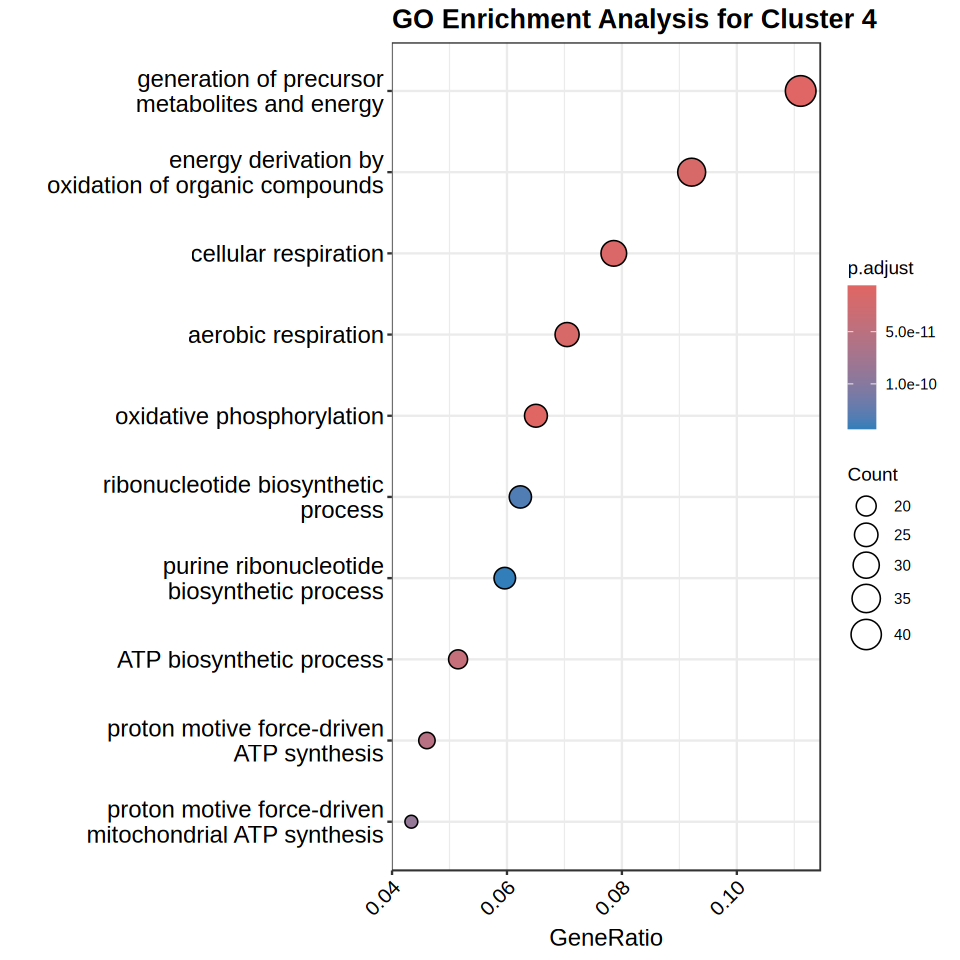

In [ ]:
# Visualize GO results
options(repr.plot.width = 8, repr.plot.height = 8)
p <- dotplot(go_result, showCategory = 10) + 
    ggtitle("GO Enrichment Analysis for Cluster 7") +
    theme(plot.title = element_text(size = 16, face = "bold"),
          axis.text.y = element_text(size = 14),
          axis.text.x = element_text(size = 12, angle = 45, hjust = 1),
          axis.title = element_text(size = 14)) +
    scale_size(range = c(3, 8))

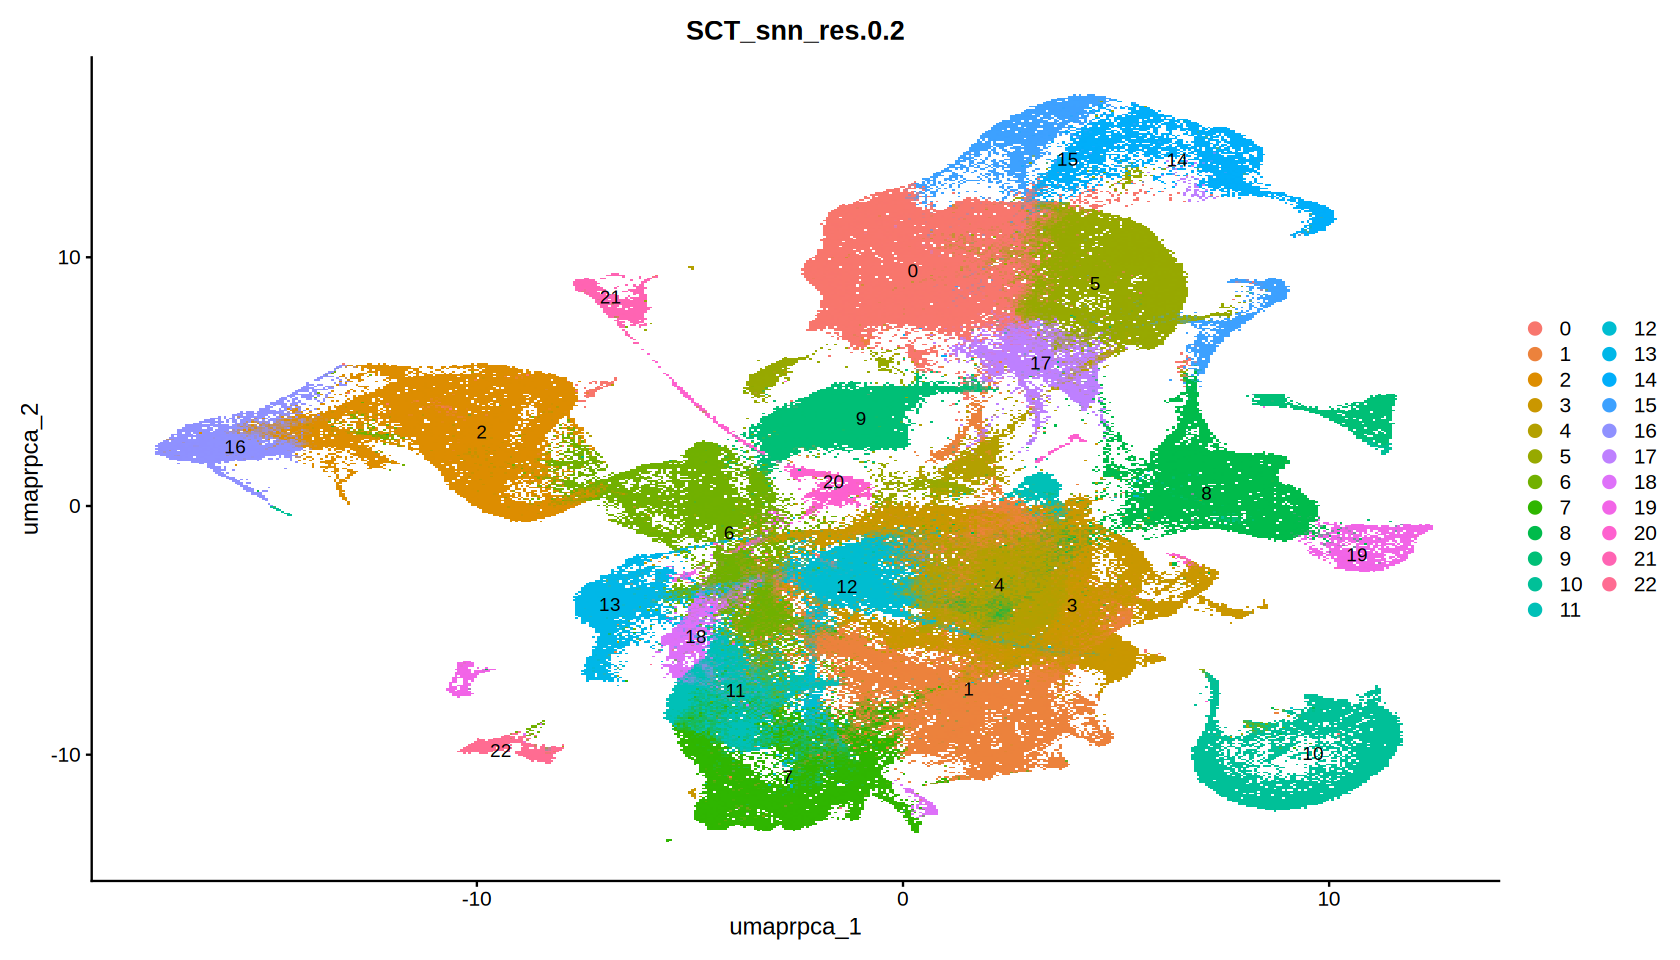

In [61]:
p2

In [ ]:
# Resolution 0.2:

# 0, 5, 8, 15, 14, 17: Myeloid 
# 1, 11: Astrocyte-like 
# 2, 16, 6: TILs => Double check with 6 
# 3:Mature_Astrocytes
# 4: MES-like
# 7: SynOPC-like 
# 9: CTAs
# 10: Mature_Oligodendrocytes
# 12: Proliferating Tumor Cells
# 13: Proneural_OPC_like
# 18: Neural Progenitor Like Cells (NPC like)
# 19: Endothelial => CHECK
# 20: Pericytes
# 21: B cells
# 22: Excitatory Neurons (Glutamatergic Neurons)

In [49]:
rpca_obj@meta.data <- rpca_obj@meta.data %>%
    mutate(general_cell_type = case_when(
        SCT_snn_res.0.2 %in% c(0, 5, 8, 15, 14, 17) ~ "Myeloid",
        SCT_snn_res.0.2 %in% c(21) ~ "B_cell",        
        SCT_snn_res.0.2 %in% c(2, 16, 6) ~ "TILs",
        SCT_snn_res.0.2 %in% c(10) ~ "Mature_Oligodendrocyte",
        SCT_snn_res.0.2 %in% c(20) ~ "Pericyte",
        SCT_snn_res.0.2 %in% c(19) ~ "Endothelial",
        SCT_snn_res.0.2 %in% c(9) ~ "CTAs",
        SCT_snn_res.0.2 %in% c(1, 11, 3) ~ "Astrocyte_like",
        SCT_snn_res.0.2 %in% c(7) ~ "Syn_OPC_like",
        SCT_snn_res.0.2 %in% c(12) ~ "Proliferating_Tumor_Cells",
        SCT_snn_res.0.2 %in% c(18) ~ "NPC_like",
        SCT_snn_res.0.2 %in% c(4) ~ "Mesenchymal_like",
        SCT_snn_res.0.2 %in% c(22) ~ "Excitatory_Neurons",
        SCT_snn_res.0.2 %in% c(13) ~ "Proneural_OPC_like",        
        TRUE ~ NA_character_
    ))

head(rpca_obj@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters,general_cell_type
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAAGTCAAGCG-1,PRJNA1125010,6520,1839,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,6.1196319,singlet,⋯,6,20,19,18,22,17,13,11,11,TILs
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCACATTGCCGG-1,PRJNA1125010,4533,1962,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,14.7804986,singlet,⋯,3,17,12,23,18,29,27,32,32,Astrocyte_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAGTACGGATG-1,PRJNA1125010,1825,671,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,23.5616438,singlet,⋯,6,18,23,27,31,30,41,28,28,TILs
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAAAGCTCTGTA-1,PRJNA1125010,50471,7374,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,7.7450417,singlet,⋯,7,3,15,16,12,12,16,12,12,Syn_OPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAATCCCATAAG-1,PRJNA1125010,41082,7762,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,5.9661165,singlet,⋯,6,18,23,27,31,30,41,28,28,TILs
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGCTAGTCACTAC-1,PRJNA1125010,11161,3306,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,0.5286265,singlet,⋯,7,3,15,16,12,12,16,12,12,Syn_OPC_like


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



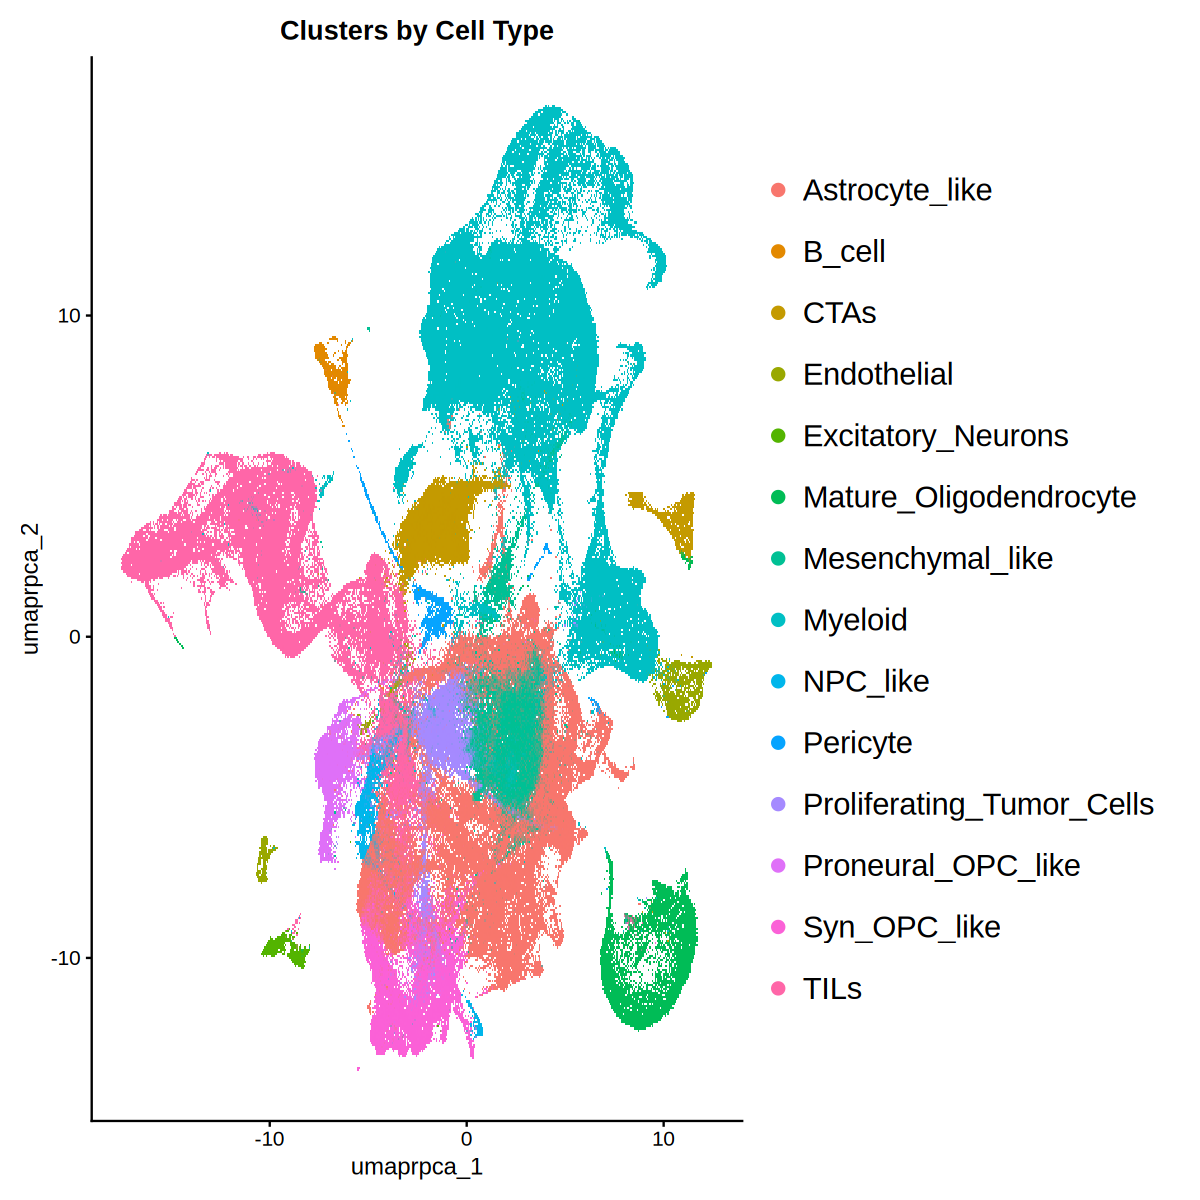

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)

DimPlot(rpca_obj, reduction = "umap.rpca", group.by = "general_cell_type", label = F, label.size = 8, repel = TRUE) + 
    ggtitle("Clusters by Cell Type") +
    theme(
        legend.text = element_text(size = 18), # Adjust size as needed
        legend.title = element_text(size = 14), # Optionally adjust legend title size
        legend.key.height = unit(1.3, "cm") # Make legend items sparser
    )

In [ ]:
# Save object
saveRDS(rpca_obj, '/mnt/18T/chibao/gliomas/data_official/01_integrated_obj/new/obj/02_rpca_integrated_orig.ident_annotated.rds')

In [ ]:
# clusters to remove
rem <- c("23", "32", "33")

# keep everything else
keep <- setdiff(unique(Idents(rpca_obj)), rem)

rpca_obj_cleaned <- subset(rpca_obj, idents = keep)

# verify
table(Idents(rpca_obj_cleaned))

In [ ]:
# Remove 23, 33, 32
rpca_obj_cleaned@meta.data <- rpca_obj_cleaned@meta.data %>%
    mutate(general_cell_type = case_when(
        SCT_snn_res.0.4 %in% c(0, 8, 6, 15, 26, 19, 4, 29) ~ "Myeloid",
        SCT_snn_res.0.4 %in% c(30) ~ "B_cell",        
        SCT_snn_res.0.4 %in% c(14, 1, 20, 18) ~ "TILs",
        SCT_snn_res.0.4 %in% c(11) ~ "Mature_Oligodendrocyte",
        SCT_snn_res.0.4 %in% c(28) ~ "Pericyte",
        SCT_snn_res.0.4 %in% c(27) ~ "Endothelial",
        SCT_snn_res.0.4 %in% c(5) ~ "CTAs",
        SCT_snn_res.0.4 %in% c(10, 13, 9, 7, 21) ~ "Astrocyte_like",
        SCT_snn_res.0.4 %in% c(3) ~ "Syn_OPC_like",
        SCT_snn_res.0.4 %in% c(12) ~ "Proliferating_Tumor_Cells",
        SCT_snn_res.0.4 %in% c(25, 22) ~ "NPC_like",
        SCT_snn_res.0.4 %in% c(2, 17, 24) ~ "Mesenchymal_like",
        SCT_snn_res.0.4 %in% c(31) ~ "Excitatory_Neurons",
        SCT_snn_res.0.4 %in% c(16) ~ "Proneural_OPC_like",        
        TRUE ~ NA_character_
    ))

head(rpca_obj_cleaned@meta.data)

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)

p <- DimPlot(rpca_obj_cleaned, reduction = "umap.rpca", group.by = "general_cell_type", label = F, label.size = 8, repel = TRUE) + 
    ggtitle("Clusters by Cell Type") +
    theme(
        legend.text = element_text(size = 18), # Adjust size as needed
        legend.title = element_text(size = 14), # Optionally adjust legend title size
        legend.key.height = unit(1.3, "cm") # Make legend items sparser
    )